## COMP9321 25T3 Assignment 1 v1.0 (15 marks)

Airbnb is an online platform that allows hosts to advertise stays on the Airbnb website. The New York-based Housing Justice Data Lab maintains public datasets to help understand Airbnb's impact on residential communities.

This assignment uses modified Airbnb data for Sydney:

- `listings.csv`: Listing information to help people book stays.
- `reviews.csv`: Review data from guests, including comments and reviewer info.
- `neighbourhoods.geojson`: Geographic boundary data for Sydney neighbourhoods.

You can download all files a zip file from: [https://drive.google.com/file/d/1ICB0P593g90gJZAd-Lyy4dKrjJ1reHJ_/view?usp=sharing]

### Assignment Instructions

Failure to follow these rules may result in penalties during marking. 

#### Environment Setup
- Use the provided `requirements.txt` to set up your virtual environment.
- Use only libraries available in the virtual environment (e.g., `pandas`, `matplotlib`).
- Use Python **3.13** only.

#### Your Answers!
In this assignment you will need to provide three types of the answers as explained in each question:
- Dataframe/Table as an output
    - Use the code cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#code-cells] where you see **# YOUR CODE GOES HERE**. If the last line of your code is the result dataframe, notebook will automatically display the results. 
- Plots (visualizations)
   - Use the code cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#code-cells] where you see **# YOUR CODE GOES HERE**. For plots/images you need to have **plt.show()** as the last line of your code. 
- Explanation
  - Use markdown cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#markdown-cells] 

#### Coding Standards
- Do **not** use `for` or `while` loops over DataFrame rows or Series.
- Do **not** convert DataFrames to native Python types (`list`, `dict`) for processing.
- Plots/Dataframes answering the questions must be shown in the notebook output. For each quesion, there must be ONLY a single notebook Cell to answer each question and its output should reflect your answer. You must make sure you include all outputs before subbmitting your notebook file. 
- Do **not** modify the provided code template structure; instead add your code where indicated by "YOUR CODE GOES HERE"
- You may write helper functions inside the codeblock for the question where it is used.
- Pandas Operations- Your solutions should leverage efficient native Pandas operations (such as apply, drop, read_csv, etc.) rather than manual or iterative approaches. Additionally, ensure that DataFrames are properly indexed and sorted to enhance readability and facilitate easier data exploration. Finally, code efficiency and cleaness is part of marking critria.

#### Visualization Standards
For the questions 4, 5, and 6 make sure you:
- Choose a suitable chart type for the data.
- Use appropriate scale and colour.
- Include title, axis labels, and legend with readable sizing.
- Ensure the visualisation is self-explanatory and informative.
- You may use sub-plots inside one window to fit multiple visualisations.
#### Submission
- You can use WebCMS to submit your notebook file which should be named **zid.ipynb** (e.g., z123456.ipynb). You only need to submit the notebook file
- Make sure you include all the outputs in the notebook file (runn all cells before submisoion) otherwise you will be penalized by 50% of the question.
- Late submission is allowed with 5% penaluty per day - You can submit no later than 5 days.
- Link for submission: [https://webcms3.cse.unsw.edu.au/COMP9321/25T3/resources/114681]

## Run this prior to your question blocks.

In [2]:
# Make sure you copy the dataset files in the same directory of your notbook

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 5)
pd.set_option('display.max_columns', None)
listings_df = pd.read_csv('listings.csv')
reviews_df = pd.read_csv('reviews.csv')
neighbourhoods_df = gpd.read_file('neighbourhoods.geojson')

In [3]:
listings_df.columns

Index(['ID ', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'Host ID',
       'host_url', 'Host Name ', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'Neighbourhood ',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'Room Type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'Price ',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm',

# Question 1 (3 marks)

You need to clean both **listings_df** and **reviews_df**  dataframes by applging best data wranggling practices. Included but not limited to checking for missing values, unexpected data types, removing unnecessary columns, setting proper index , and any obvious data quality issues. It is part of the assignment to explore the datasets and the assignment requirments (including all questions) and clean the dataset as much as you can.  


**Marking Criteria**
- [2 marks]  Properly cleaned dataframes using pandas operations
- [1 mark]   Properly list all of the steps and why the step is required for a cleaned dataset


In [4]:
# YOUR CODE GOES HERE - Clean the listings dataframe, name it (listings_df) and show the dataframe as output of your cell

# Step 1: Formating each columns
listings_df.columns = listings_df.columns.str.strip().str.lower().str.replace(' ', '_')

# Step 2: Select columns that we need for analyze
price_prediction = ['property_type', 'room_type', 'accommodates','bedrooms','beds',
                    'bathrooms_text','neighbourhood_cleansed','latitude','longitude'
                    'host_is_superhost','host_identity_verified','review_scores_rating','reviews_per_month','number_of_reviews','amenities','price']

room_availability = ['availability_30','availability_60','availability_90','availability_365','minimum_nights','maximum_nights','calendar_updated','has_availability','review_scores_location','review_scores_value']

major_cols = [
    'id', 'host_id', 'host_listings_count', 'neighbourhood_cleansed',
    'property_type', 'room_type', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
    'maximum_nights', 'availability_30', 'availability_365', 'number_of_reviews',
    'reviews_per_month', 'review_scores_rating', 'host_response_rate',
    'instant_bookable', 'first_review', 'last_review'
]

#listings_df = listings_df[price_prediction]
#listing_df = listings_df[room_availability]
listings_df = listings_df[major_cols]


# Step 3 Formating untidy columns

listings_df['price'] = listings_df['price'].replace('[\$,]', '', regex=True).astype(float)
listings_df['host_response_rate'] = listings_df['host_response_rate'].str.replace('%', '').astype(float)
listings_df['instant_bookable'] = listings_df['instant_bookable'].map({'t': True, 'f': False})
listings_df['first_review'] = pd.to_datetime(listings_df['first_review'], errors='coerce')
listings_df['last_review'] = pd.to_datetime(listings_df['last_review'], errors='coerce')

listings_df.drop_duplicates(inplace=True)
listings_df.dropna(subset=['host_id', 'neighbourhood_cleansed', 'price'], inplace=True)


listings_df.set_index('id', inplace=True)

# Do not change the following lines of code (this will print the dataframe as an output after running the cell)
listings_df



,host_id,host_listings_count,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,availability_30,availability_365,number_of_reviews,reviews_per_month,review_scores_rating,host_response_rate,instant_bookable,first_review,last_review
id,,,,,,,,,,,,,,,,,,,,,,
11156,40855.0,1.0,Sydney,Private room in rental unit,private room,1,1.0,1.0,1.0,"[""Refrigerator"", ""Dishwasher"", ""Kitchen"", ""Was...",65.0,90,180,28,363,193,1.02,4.59,NaN,False,2009-12-05,2020-03-13
15253,59850.0,1.0,Sydney,Private room in condo,private room,2,1.0,1.0,1.0,"[""Portable fans"", ""Refrigerator"", ""Dishwasher""...",99.0,1,90,22,310,617,3.81,4.54,100.0,True,2012-02-23,2025-05-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436702889846115081,659513428.0,16.0,Sydney,Private room in rental unit,private room,2,1.0,1.0,1.0,"[""Private living room"", ""Refrigerator"", ""Kitch...",75.0,7,365,15,15,0,NaN,NaN,100.0,False,NaT,NaT
1436718439288951566,547018083.0,40.0,Sydney,Entire rental unit,entire home/apt,2,1.0,1.0,1.0,"[""Refrigerator"", ""Dishwasher"", ""Kitchen"", ""Was...",121.0,5,365,13,13,0,NaN,NaN,89.0,False,NaT,NaT


In [5]:
# YOUR CODE GOES HERE - Clean the reviews dataframe, name it (reviews_df) and show the dataframe as output of your cell
import re

reviews_df.columns = reviews_df.columns.str.strip().str.lower().str.replace(' ', '_')

major_cols = ['id', 'listing_id', 'date', 'reviewer_id', 'reviewer_name', 'comments']
reviews_df = reviews_df[major_cols]

reviews_df['date'] = pd.to_datetime(reviews_df['date'], errors='coerce')
reviews_df['comments'] = reviews_df['comments'].apply(lambda x: re.sub(r'[^\w\s]', '', str(x)).strip())

reviews_df.drop_duplicates(inplace=True)
reviews_df.dropna(subset=['listing_id', 'date'], inplace=True)
assert reviews_df['id'].is_unique, "The 'id' column is not unique."
reviews_df.set_index('id', inplace=True)

# Do not change the following lines of code
reviews_df 


,listing_id,date,reviewer_id,reviewer_name,comments
id,,,,,
19220,11156,2009-12-05,52946,Jeff,Colleen was friendly and very helpful regardin...
32592,11156,2010-03-31,99382,Michael,Great place centrally located easy walk to tra...
...,...,...,...,...,...
1427178633031992838,1421627348236436828,2025-05-22,662525224,Roland,Jonny was an excellent hostgave us advice on t...
1440238555926021523,1421627348236436828,2025-06-09,51103659,Tamara,Had such a fantastic stay Amazing location and...


In [6]:
# do not remove this cell
listings_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15420 entries, 11156 to 1436718439288951566
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   host_id                 15420 non-null  float64       
 1   host_listings_count     15418 non-null  float64       
 2   neighbourhood_cleansed  15420 non-null  object        
 3   property_type           15420 non-null  object        
 4   room_type               15420 non-null  object        
 5   accommodates            15420 non-null  int64         
 6   bathrooms               15415 non-null  float64       
 7   bedrooms                15402 non-null  float64       
 8   beds                    15382 non-null  float64       
 9   amenities               15420 non-null  object        
 10  price                   15420 non-null  float64       
 11  minimum_nights          15420 non-null  int64         
 12  maximum_nights          15420 non

In [7]:
# do not remove this cell
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 670552 entries, 19220 to 1440238555926021523
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   listing_id     670552 non-null  int64         
 1   date           670552 non-null  datetime64[ns]
 2   reviewer_id    670552 non-null  int64         
 3   reviewer_name  670551 non-null  object        
 4   comments       670552 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 30.7+ MB


# Question 2 (2 mark)

Merge the cleaned listings and reviews datasets into a single DataFrame. Join the result dataframe with the neighbourhoods dataset - the result dataframe should add two extra columns named 'latitude' and 'longitude' which shows the center of the neighbourhood. You should also clean the result dataset. 

**Marking Criteria**
- [1 mark]  Join Listings and Reviews dataframes
- [1 mark]  Join the result dataframe with the neighbourhoods dataset - the result dataframe should add two columns to the merged column named 'latitude' and 'longitude' which shows the center of the neighbourhood

In [8]:
neighbourhoods_df.columns

Index(['neighbourhood', 'neighbourhood_group', 'geometry'], dtype='object')

In [9]:
# YOUR CODE GOES HERE - join all dataframes and name it merged_df
#neighbourhoods_df = neighbourhoods_df.drop(columns = ['neighbourhood_group'], inplace = True)
neighbourhoods_df['latitude'] = neighbourhoods_df.geometry.centroid.y
neighbourhoods_df['longitude'] = neighbourhoods_df.geometry.centroid.x
neighbourhoods_df['centroid'] = neighbourhoods_df.geometry.centroid

merged_df = reviews_df.merge(listings_df, left_on = 'listing_id', right_index = True, how = 'inner')
merged_df = merged_df.merge(neighbourhoods_df, left_on ='neighbourhood_cleansed', right_on = 'neighbourhood',how = 'left')


#merged_df.dropna(subset=['listing_id', 'latitude', 'longitude'], inplace=True)
#merged_df = merged_df.drop(columns = ['comments','listing_url','neighbourhood_group'], inplace = True)
merged_df.reset_index(drop=True, inplace=True)

merged_df

,listing_id,date,reviewer_id,reviewer_name,comments,host_id,host_listings_count,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,availability_30,availability_365,number_of_reviews,reviews_per_month,review_scores_rating,host_response_rate,instant_bookable,first_review,last_review,neighbourhood,neighbourhood_group,geometry,latitude,longitude,centroid
0,11156,2009-12-05,52946,Jeff,Colleen was friendly and very helpful regardin...,40855.0,1.0,Sydney,Private room in rental unit,private room,1,1.0,1.0,1.0,"[""Refrigerator"", ""Dishwasher"", ""Kitchen"", ""Was...",65.0,90,180,28,363,193,1.02,4.59,NaN,False,2009-12-05,2020-03-13,Sydney,None,"MULTIPOLYGON (((151.20872 -33.85365, 151.20872...",-33.889671,151.202739,POINT (151.20274 -33.88967)
1,11156,2010-03-31,99382,Michael,Great place centrally located easy walk to tra...,40855.0,1.0,Sydney,Private room in rental unit,private room,1,1.0,1.0,1.0,"[""Refrigerator"", ""Dishwasher"", ""Kitchen"", ""Was...",65.0,90,180,28,363,193,1.02,4.59,NaN,False,2009-12-05,2020-03-13,Sydney,None,"MULTIPOLYGON (((151.20872 -33.85365, 151.20872...",-33.889671,151.202739,POINT (151.20274 -33.88967)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611461,1421627348236436828,2025-05-22,662525224,Roland,Jonny was an excellent hostgave us advice on t...,44992829.0,2.0,Woollahra,Entire rental unit,entire home/apt,2,1.0,1.0,1.0,"[""Ceiling fan"", ""Refrigerator"", ""Dishwasher"", ...",232.0,2,365,25,73,2,2.00,5.00,100.0,False,2025-05-22,2025-06-09,Woollahra,None,"MULTIPOLYGON (((151.28054 -33.83286, 151.28062...",-33.871762,151.257389,POINT (151.25739 -33.87176)
611462,1421627348236436828,2025-06-09,51103659,Tamara,Had such a fantastic stay Amazing location and...,44992829.0,2.0,Woollahra,Entire rental unit,entire home/apt,2,1.0,1.0,1.0,"[""Ceiling fan"", ""Refrigerator"", ""Dishwasher"", ...",232.0,2,365,25,73,2,2.00,5.00,100.0,False,2025-05-22,2025-06-09,Woollahra,None,"MULTIPOLYGON (((151.28054 -33.83286, 151.28062...",-33.871762,151.257389,POINT (151.25739 -33.87176)


# Question 3 (2 marks)
Airbnb wants to better understand how the scale of a host's operation (i.e. the number of listings they manage) affects key business metrics such as pricing, availability, and guest experience — particularly in relation to the amenities they offer.

You are tasked with building a pivot table that summarizes host performance per amenity and per host segment.

- Small Portfolio: 1 listing
- Medium Portfolio: 2–5 listings
- Large Portfolio: 6–10 listings
- Enterprise Portfolio: 10+ listings


Using the provided Airbnb dataset, your task is to:
- Focus on a shortlist of key amenities:
    - WiFi, Kitchen, Air conditioning, Heating, TV, Washer, Free parking
- Create a pivot table that shows, for each combination of host segment and amenity:
    - Average nightly price
    - Average availability in the next 30 days
    - Average review score rating

**Marking Criteria**
- [1 mark]  A proper dataframe as an output to fullfil the requirment
- [1 mark]  Interpretation of your results and justification of your analysis- Add comments to your code explaining what conlustion you can draw from the results

In [10]:
# YOUR CODE GOES HERE - your pivot table should be named summary - All of the rows of this table should be shown
# Step 1: Select key facilities
amenities = ['WiFi','Kitchen','Air conditioning','Heating','TV','Washer','Free parking']

# Step 2: Construct host segment function
def classify_host_segment(listing_count):
    return (
        'Small Portfolio' if listing_count == 1 else
        'Medium Portfolio' if 2 <= listing_count <= 5 else
        'Large Portfolio' if 6 <= listing_count <= 10 else
        'Enterprise Portfolio'
    )

# Step 3: Apply classify_host_segment function and create a new column host_segment
listings_df['host_segment'] = listings_df['host_listings_count'].map(classify_host_segment)

# Step 4: Check if amenity is provided

listings_df['WiFi'] = listings_df['amenities'].str.contains('WiFi', case=False, na=False)
listings_df['Kitchen'] = listings_df['amenities'].str.contains('Kitchen', case=False, na=False)
listings_df['Air conditioning'] = listings_df['amenities'].str.contains('Air conditioning', case=False, na=False)
listings_df['Heating'] = listings_df['amenities'].str.contains('Heating', case=False, na=False)
listings_df['TV'] = listings_df['amenities'].str.contains('TV', case=False, na=False)
listings_df['Washer'] = listings_df['amenities'].str.contains('Washer', case=False, na=False)
listings_df['Free parking'] = listings_df['amenities'].str.contains('Free parking', case=False, na=False)


# Step 4: Convert the data into long format to create a pivot table

melt_listings_df = listings_df.melt(
    id_vars = ['host_segment','price', 'availability_30', 'review_scores_rating'],
    value_vars = amenities,
    var_name = 'amenity',
    value_name = 'has_amenity'
)

# Step 5: Select the column

amenities_df = melt_listings_df[melt_listings_df['has_amenity']]

# Step 6: Create Pivot table
summary = amenities_df.pivot_table(
    index=['host_segment', 'amenity'],
    values = ['price', 'availability_30', 'review_scores_rating'],
    aggfunc = 'mean'
).round(2)


# Do not change the following lines of code
pd.set_option('display.max_rows', 50)
summary

availability_30   price  \
host_segment         amenity                                     
Enterprise Portfolio Air conditioning            14.94  417.48   
                     Free parking                15.33  426.01   
                     Heating                     14.65  386.32   
                     Kitchen                     14.98  370.81   
                     TV                          14.81  399.63   
                     Washer                      14.91  366.94   
                     WiFi                        15.22  370.19   
Large Portfolio      Air conditioning            15.33  300.28   
                     Free parking                15.14  361.00   
                     Heating                     15.13  299.65   
                     Kitchen                     15.08  286.29   
                     TV                          15.36  297.35   
                     Washer                      15.13  283.50   
                     WiFi                        15.54  281.05   
Medium Portfolio     Air conditioning            15.38  308.13   
                     Free parking                15.78  336.30   
                     Heating                     15.09  289.03   
                     Kitchen                     15.28  288.96   
                     TV                          15.32  297.84   
                     Washer                      15.27  289.66   
                     WiFi                        15.49  283.04   
Small Portfolio      Air conditioning            15.95  401.73   
                     Free parking                16.76  425.24   
                     Heating                     15.12  381.34   
                     Kitchen                     15.80  363.39   
                     TV                          15.63  368.40   
                     Washer                      15.77  368.37   
                     WiFi                        15.73  358.33   

                                       review_scores_rating  
host_segment         amenity                                 
Enterprise Portfolio Air conditioning                  4.63  
                     Free parking                      4.63  
                     Heating                           4.64  
                     Kitchen                           4.59  
                     TV                                4.64  
                     Washer                            4.58  
                     WiFi                              4.59  
Large Portfolio      Air conditioning                  4.69  
                     Free parking                      4.70  
                     Heating                           4.70  
                     Kitchen                           4.70  
                     TV                                4.70  
                     Washer                            4.70  
                     WiFi                              4.69  
Medium Portfolio     Air conditioning                  4.75  
                     Free parking                      4.75  
                     Heating                           4.77  
                     Kitchen                           4.77  
                     TV                                4.77  
                     Washer                            4.76  
                     WiFi                              4.76  
Small Portfolio      Air conditioning                  4.84  
                     Free parking                      4.83  
                     Heating                           4.85  
                     Kitchen                           4.83  
                     TV                                4.84  
                     Washer                            4.83  
                     WiFi                              4.84

### Inerpreration of Results for Question 3 - 

[Place holder for your explanation in md format - https://www.markdownguide.org/basic-syntax/]


# Question 4 (2.5 marks)

Provide two actionable recommendations supported by appropriate chart(s):
- One for new hosts entering the market
- One for existing hosts to improve performance

**Marking Criteria:**
- [2 marks] The recommendations are actionable and valuable to the stakeholder to achieve their objectives. Add comments to explain the results
- [0.5 marks] The visualisation maintained a professional standard of visual quality, clarity, formatting, and correctness.



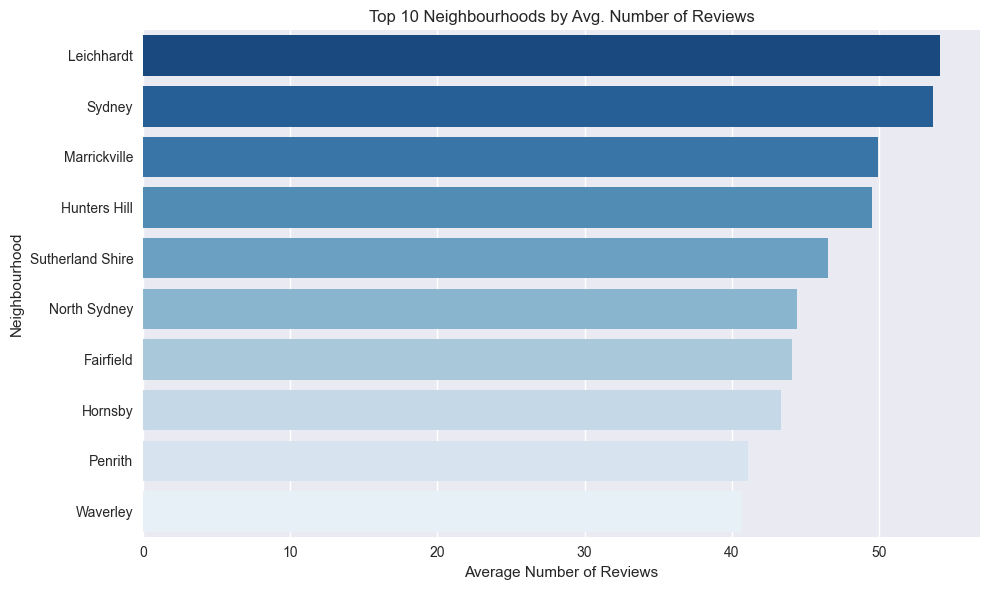

In [13]:
# YOUR CODE GOES HERE - your visualization must be shown as an output at the end of this cell 
#                      (do not store the image - it should be shown after this cell once you run this cell)


# For new hosts entering the market - Based on number_of_reviws to select high demand district
listings_df.columns = listings_df.columns.str.strip()

# Calculate number of reviews based on district
top_neighbourhoods = (
    listings_df.groupby('neighbourhood_cleansed')['number_of_reviews']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# plot top_neighbourhoods
plt.figure(figsize=(10, 6))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, palette='Blues_r')
plt.title('Top 10 Neighbourhoods by Avg. Number of Reviews')
plt.xlabel('Average Number of Reviews')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()


### Explanation of Results for Question 4

[Place holder for your explanation]

# Question 5 (2.5 marks)

Airbnb would like to investigate whether the timing of reviews and the quality of listings impact user engagement. As a data analyst, your task is to verify or challenge the following claim:

“Listings tend to receive more reviews during weekends or public holidays in NSW. Additionally, listings with higher ratings tend to attract more reviews and are managed by hosts with higher response rates.”

**Marking Criteria:**
- [2 marks] The analysis/charts effectively identifies trends and patterns.
- [0.5 marks] The visualisation maintained a professional standard of visual quality, clarity, formatting, and correctness.



In [ ]:
reviews_df

,listing_id,date,reviewer_id,reviewer_name,comments
id,,,,,
19220,11156,2009-12-05,52946,Jeff,Colleen was friendly and very helpful regardin...
32592,11156,2010-03-31,99382,Michael,Great place centrally located easy walk to tra...
42280,11156,2010-05-14,105797,Marina,Colleen is very friendly and helpful The apart...
140942,11156,2010-11-17,259213,Sigrid,Dear Colleen\rbrMy friend Diemut from Germany ...
151966,11156,2010-12-11,273389,Eduardo,Lovely interesting chats and very helpful givi...
...,...,...,...,...,...
1433784142877792123,1421572362905165610,2025-06-01,73808465,Ofa,We stayed at Muugis place over 3 nights and en...
1437364344763939541,1421572362905165610,2025-06-06,536898889,Chloe Lorraine,Such a lovely place to stay service was amazin...
1439502267512865547,1421572362905165610,2025-06-08,203786095,Saipele,Thank you Muggii for your care and kindness th...


In [ ]:
# YOUR CODE GOES HERE - your visualization must be shown as an output at the end of this cell 
#                      (do not store the image - it should be showon after this cell once you run this cell)

import holidays

# Step 1: Process datetime data
reviews_df['date'] = pd.to_datetime(reviews_df['date'])
reviews_df['day_of_week'] = reviews_df['date'].dt.dayofweek
reviews_df['is_weekend'] = reviews_df['day_of_week'] >= 5

# Step 2: Select NSW holiday 
nsw_holidays = holidays.Australia(prov='NSW', years = reviews_df['date'].dt.year.unique())
reviews_df['is_holiday'] = reviews_df['date'].isin(nsw_holidays)

#plt.show()

### Explanation of Results for Question 5

[Place holder for your explanation]

# Question 6 (3 marks)

Create visualisation(s) to outline notable points to the community about the price distributions in Sydney based on listing and neighbourhood information.


**Marking Criteria:**
- [2.5 marks] The visualisation had depth and relevance to the community about price distributions in Sydney.
- [0.5 marks] The visualisation maintained a professional standard of visual quality, clarity, formatting, and correctness.

In [ ]:
# YOUR CODE GOES HERE - your visualization must be shown as an output at the end of this cell 
#                      (do not store the image - it should be showon after this cell once you run this cell)
plt.show()

### Explanation of Results for Question 6

[Place holder for your explanation]